Cargando modelo desde: /home/sebastian/Documents/Programming/Python/scode-geoai-analysis/ml_project/notebooks/deforestation_model_optimized.pkl
Muestras de prueba cargadas: 13422 píxeles.
Realizando predicciones en el conjunto de prueba...

--- REPORTE DE CLASIFICACIÓN ---
                   precision    recall  f1-score   support

Otras Tierras (0)       0.92      0.91      0.91      4457
       Bosque (1)       0.88      0.87      0.87      4448
  Deforestado (2)       0.81      0.84      0.83      4517

         accuracy                           0.87     13422
        macro avg       0.87      0.87      0.87     13422
     weighted avg       0.87      0.87      0.87     13422


Precisión General (Accuracy): 0.8711
Generando Matriz de Confusión...
Matriz de confusión guardada como 'confusion_matrix_final.png'


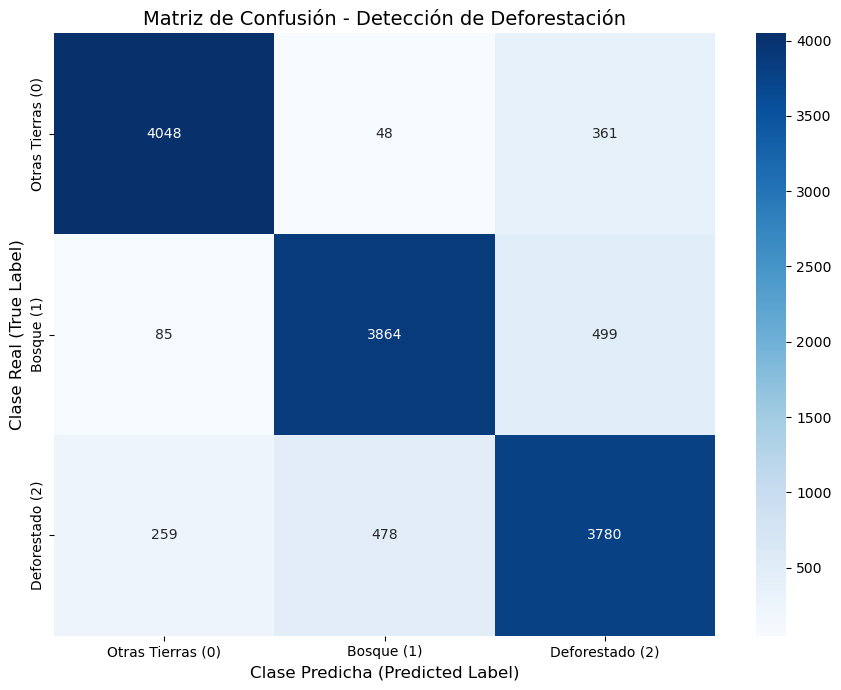

In [2]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- CONSTANTES ---
MODEL_FILENAME = '/home/sebastian/Documents/Programming/Python/scode-geoai-analysis/ml_project/notebooks/deforestation_model_optimized.pkl'
TEST_SAMPLES_FILE = '/home/sebastian/Documents/Programming/Python/scode-geoai-analysis/ml_project/notebooks/testing_optimized.csv'
CLASS_LABELS = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
TARGET_COLUMN = 'class' 

# --- PASO 1: CARGAR MODELO Y DATOS DE PRUEBA ---
print(f"Cargando modelo desde: {MODEL_FILENAME}")
try:
    classifier = joblib.load(MODEL_FILENAME)
    test_df = pd.read_csv(TEST_SAMPLES_FILE)
    print(f"Muestras de prueba cargadas: {len(test_df)} píxeles.")
except FileNotFoundError as e:
    print(f"Error: Asegúrese de que los archivos existan: {e}")
    exit()

# --- CONSTANTES ---
# ... (otras constantes, asumiendo que 'features' se define correctamente)
TARGET_COLUMN = 'class' 
# Las características que se usaron en el entrenamiento (definidas en el notebook):
EXPECTED_FEATURES = [
    # Bandas espectrales básicas
    'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2',
    # Índices de vegetación (básicos)
    'NDVI', 'EVI', 'SAVI', 'NDWI',
    # Índices mejorados
    'NBR', 'MNDWI', 'GNDVI', 'NDMI', 'BSI', 'EVI2',
    # Características temporales mejoradas
    'NDVI_2024', 'NDVI_2023', 'NDVI_2022',
    'NDVI_diff_2024_2023', 'NDVI_diff_2023_2022', 'NDVI_diff_2024_2022', 'NDVI_diff_2024_2020',
    'NDVI_ratio_2024_2023', 'NDVI_mean_3yr', 'NDVI_trend',
    # Topografía
    'elevation', 'slope',
    # Textura (GLCM) - múltiples bandas
    'NIR_entropy', 'NIR_contrast', 'NIR_homogeneity', 'NIR_variance',
    'Red_entropy', 'Red_contrast', 'Red_homogeneity', 'Red_variance',
    'NDVI_entropy', 'NDVI_contrast', 'NDVI_homogeneity', 'NDVI_variance'
]


# --- PASO 1: CARGAR MODELO Y DATOS DE PRUEBA ---
# ... (código de carga omitido por brevedad)

# Separar características (X) y objetivo (y)
test_df = pd.read_csv(TEST_SAMPLES_FILE)

# 1. IDENTIFICAR CARACTERÍSTICAS:
# Usamos la lista de características esperadas (EXPECTED_FEATURES) para la selección.
# Esto asegura que no se incluyan columnas como 'system:index' o 'random'.
X_test_initial = test_df[EXPECTED_FEATURES] # <--- Seleccionamos SOLO las columnas esperadas

# 2. APLICAR EL ORDEN CRÍTICO:
# Forzamos que X_test tenga las columnas en el orden exacto de EXPECTED_FEATURES.
X_test = X_test_initial[EXPECTED_FEATURES] # <--- Esto es CRUCIAL para Scikit-learn

y_test = test_df[TARGET_COLUMN]

# --- PASO 2: REALIZAR PREDICCIONES (CORREGIDO) ---
print("Realizando predicciones en el conjunto de prueba...")
# La predicción ahora funciona porque X_test tiene los nombres y el orden correcto
y_pred = classifier.predict(X_test) 

# --- PASO 3: EVALUACIÓN DEL MODELO ---
# ... (código de evaluación que ya funciona)
# Separar características (X) y objetivo (y)
# Excluimos las columnas que no son features (ej. 'system:index', 'random', 'class')
# --- PASO 3: EVALUACIÓN DEL MODELO (Métricas) ---
print("\n--- REPORTE DE CLASIFICACIÓN ---")
# Generar el reporte con precisión, recall y F1-score
report = classification_report(y_test, y_pred, target_names=CLASS_LABELS)
print(report)

# La precisión general (accuracy) es la última línea del reporte:
accuracy = (y_test == y_pred).mean()
print(f"\nPrecisión General (Accuracy): {accuracy:.4f}")


# --- PASO 4: VISUALIZAR MATRIZ DE CONFUSIÓN ---
print("Generando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CLASS_LABELS, 
    yticklabels=CLASS_LABELS
)
plt.title('Matriz de Confusión - Detección de Deforestación', fontsize=14)
plt.ylabel('Clase Real (True Label)', fontsize=12)
plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png')
print("Matriz de confusión guardada como 'confusion_matrix_final.png'")